In [11]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, accuracy_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Datan kuvailu ja preprosessointi
1. luokitellaan data sen sisällön mukaan.

In [12]:
#Määritetään tyypit kaikille muuttujille

df = pd.read_csv('puut1.csv', 
                 index_col=0,
                 dtype={
                   "length": np.float64,
                   "diameter": np.float64,
                   "cones": np.int64,
                   "leaves": np.int64,
                   "bark_thickness": np.float64,
                   "seed_size": np.float64,
                   "fungi_present": np.float64,
                   "color_guess": np.object_,
                   "soil_pH": np.float64,
                   "collector_id": np.float64,
                   "collector_guess": np.float64,
                   }, 
                   na_values="*"
                   )

2. Tarkistetaan datan eheys

In [13]:
#Tarkistetaan onko datassa puuttuvia arvoja
print(df.isnull().sum())

numeric_vars = ["length", "diameter", "cones", "leaves", "bark_thickness", "seed_size", "soil_pH"]
categoric_vars = ["fungi_present", "color_guess"]
researcher_vars = ["collector_guess", "collector_id"]

length             0
diameter           0
cones              0
leaves             0
bark_thickness     0
seed_size          0
fungi_present      0
color_guess        0
soil_pH            0
collector_id       0
collector_guess    0
dtype: int64


In [14]:
#Tulostetaan numeeriset attribuutit ja tarkastellaan tulostusta
print(df[numeric_vars].describe().round(1))

       length  diameter  cones   leaves  bark_thickness  seed_size  soil_pH
count   300.0     300.0  300.0    300.0           300.0      300.0    300.0
mean    267.4     115.5   87.8  10689.1             1.2        1.0      8.0
std      78.9      24.8   58.5   5691.4             0.3        0.0      1.0
min      69.1      74.0  -10.0   1067.0             0.6        0.8      4.8
25%     207.4      98.3   35.8   5720.0             1.0        1.0      7.3
50%     289.6     105.6   85.5  10631.0             1.1        1.0      8.0
75%     306.4     130.8  131.2  15620.5             1.3        1.0      8.6
max     516.9     214.8  199.0  19956.0             2.2        1.2     11.8


In [15]:
#Tulostetaan kategoriset attribuutit ja tarkastellaan tulostusta
print(df[categoric_vars].astype('object').describe())

        fungi_present color_guess
count           300.0         300
unique            2.0           5
top               0.0    lightish
freq            154.0          76


In [16]:
#Tarkistetaan kategoriset muuttujat turhien luokkien varalta
for col in df[categoric_vars + researcher_vars]:
  print(f"{col:<15}: {df[col].unique()}")

fungi_present  : [0. 1.]
color_guess    : ['dark' 'light' 'mid-green' 'lightish' 'darkish']
collector_guess: [1. 2. 3.]
collector_id   : [3. 2. 1.]


In [17]:
#Korjataan virheelliset arvot käpyjen määrässä.
#Käpyjä ei voi olla negatiivista määrää.
#Oletetaan että negatiivinen etuliite on kirjoitettu vahingossa.
#Muutetaan siis kaikki arvot niiden itsearvoiksi käpyjen määrän sarakkeessa.
df.cones = df.cones.abs()

3. Datan kuvailu tilastollisilla menetelmillä

Monet tilastolliset menetelmät olettavat että data on riippumatonta ja normaalisti jakautunutta. Testataan aluksi datan jakaumaa, jonka jälkeen sovelletaan testejä dataan perustuen kuinka se on jakautunut. Tärkeimmät testit tässä tapauksessa ovat korrelaatiotestit, joiden avulla selvitetään minkä attribuuttien yhdistelmät tuottavat tarpeeksi korreloitunutta tulosta.

Korkean korrelaation attribuutit voidaan valita seuraavassa kohdassa KMeans klusteroinnin parametreiksi, jotta klusterointi olisi tehokasta. Tehokkuuteen vaikuttaa kuinka paljon attribuutit vaikuttavat attribuuttien väliseen korrelaatioon.

Kuvailun jälkeen data normalisoidaan, jotta etäisyyteen perustuvat menetelmät toimivat eri mittaluokan attribuuteilla.

In [18]:
#Käytetään Shapiro-Wilkin normaalisuus testiä numeerisen datan analysoinnissa
shapiro_test = stats.shapiro(df[numeric_vars], axis=0)
print(f'P-arvot numeeriselle datalle:')
for index, row in enumerate(shapiro_test.pvalue):
  print(f'{df[numeric_vars].columns[index]:<15} {row:<8.3} {"< 0.05" if row < 0.05  else "> 0.05"}')

P-arvot numeeriselle datalle:
length          8.83e-08 < 0.05
diameter        9.83e-15 < 0.05
cones           1.62e-08 < 0.05
leaves          6.92e-09 < 0.05
bark_thickness  4.17e-09 < 0.05
seed_size       3.07e-29 < 0.05
soil_pH         0.37     > 0.05


In [19]:
#Tulostetaan viisi eniten korreloitunutta attribuuttia

numeric_correlation = sorted(numeric_correlation, key=lambda x: x[0], reverse=True)
top5 = []

for index, row in enumerate(numeric_correlation):
  if(index % 2 == 0):
    continue
  if(index >= 10):
    break
  top5.append(row)

for row in top5:
  print(f'{row[1]:<50}: {row[0]:.4}')

correlation of length and bark_thickness          : 0.1786
correlation of length and cones                   : 0.04165
correlation of length and soil_pH                 : -0.04156


In [131]:
#Muodostetaan merkittävimpien attribuuttien lista
cluster_vars = ['diameter', 'collector_guess']

#Normalisoidaan data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cluster_vars])

# 2 Tutkimus
1. Käytetään KMeans klusterointia ja jaetaan puut kolmeen luokkaan

In [138]:
#Suoritetaan KMeans klusterointi kokeilemalla useaa aloituskohtaa
#ja iteroimalla tarpeeksi monta kertaa, jotta tulos konvergoituu

kmeans = KMeans(n_clusters=5,
                init='k-means++',
                n_init=150,
                max_iter=5000,
                random_state=42,
                )
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_

In [139]:
#Arvioidaan klusteroinnin tulosta silhouette_scoren avulla
#Samalla arvioidaan klustereiden välisiä eroja

score = silhouette_score(X_scaled, kmeans.labels_)
print(f"Silhouette Score: {score:.3f}")

sample_scores = silhouette_samples(X_scaled, kmeans.labels_)
for cluster in range(2):
    cluster_scores = sample_scores[kmeans.labels_ == cluster]
    print(f"Cluster {cluster}: mean={cluster_scores.mean():.3f}, "
          f"min={cluster_scores.min():.3f}")

Silhouette Score: 0.638
Cluster 0: mean=0.684, min=0.339
Cluster 1: mean=0.509, min=0.009


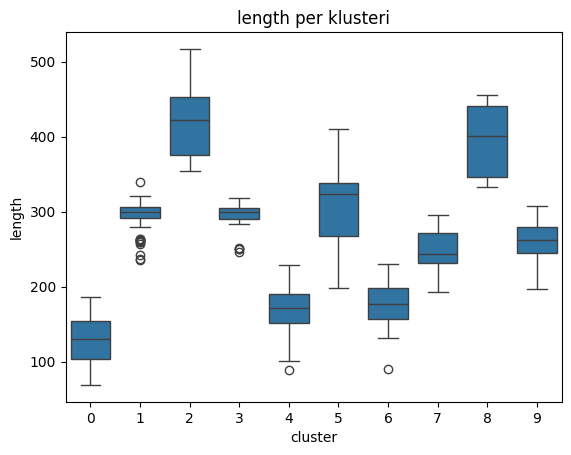

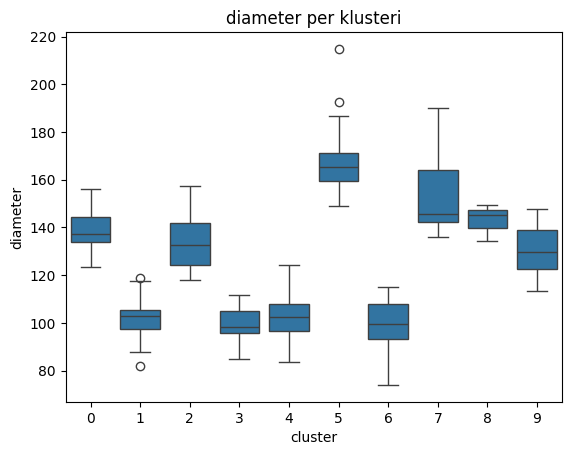

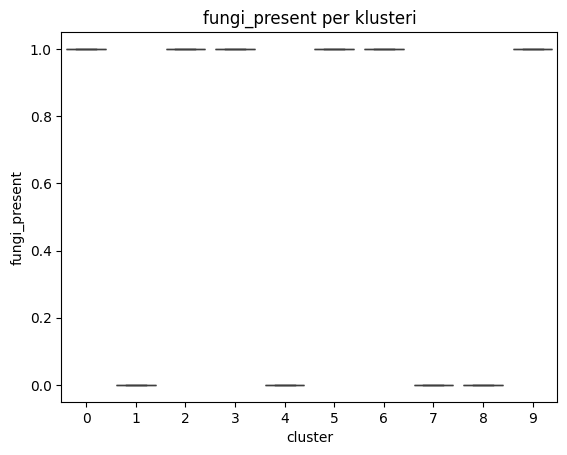

In [102]:
#Tarkastellaan myös visuaalisesti eri attribuuttien vaikutusta klusterointiin
#Tavoitteena on mahdollisimman suuri ero luokkien välillä yhdessä attribuutissa

variances = pd.Series(X_scaled.var(axis=0), index=cluster_vars)

df['cluster'] = kmeans.labels_
for feature in cluster_vars:
    sns.boxplot(data=df, x='cluster', y=feature)
    plt.title(f'{feature} per klusteri')
    plt.show()

Huomataan, että kaarnan paksuus ja halkaisija erottaa luokan 0 ja luokat 1 ja 2.
Luokan 1 ja 2 suurin ero on sienien läheisyys. klusterissa 1 ei ole sieniä ja klusterissa 2 on sieniä lähellä.

2. Arvioidaan tutkijoiden puiden luokittelua Accuracy ja F1 metriikoilla.

In [103]:
summary = df.groupby('collector_id').apply(lambda x: pd.Series({
    'total_samples' : len(x),
    'correct'       : (x['cluster'] == x['collector_guess']).sum(),
    'accuracy'      : accuracy_score(x['cluster'], x['collector_guess']),
    'recall'        : recall_score(x['cluster'], x['collector_guess'], average='weighted', zero_division=0),
})).reset_index().sort_values('accuracy', ascending=False)

print(summary)

   collector_id  total_samples  correct  accuracy    recall
1           2.0           98.0     17.0  0.173469  0.173469
0           1.0          102.0      9.0  0.088235  0.088235
2           3.0          100.0      7.0  0.070000  0.070000
